In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
dict_ = {
    'a': [11, 21, 31],
    'b': [12, 22, 32]
}

In [6]:
df = pd.DataFrame(dict_)
type(df)

pandas.DataFrame

In [7]:
df.head()

,a,b
0,11,12
1,21,22
2,31,32


In [8]:
df.mean()

a    21.0
b    22.0
dtype: float64

In [10]:
%pip install nba_api

Note: you may need to restart the kernel to use updated packages.


In [11]:
from nba_api.stats.static import teams
import matplotlib.pyplot as plt

In [21]:
def one_dict(list_dict):
    keys = list_dict[0].keys()
    out_dict = {key: [] for key in keys}
    for dict_ in list_dict:
        for key, value in dict_.items():
            out_dict[key].append(value)
    return out_dict

In [13]:
nba_teams = teams.get_teams()

In [19]:
nba_teams[0:3]

[{'id': 1610612737,
  'full_name': 'Atlanta Hawks',
  'abbreviation': 'ATL',
  'nickname': 'Hawks',
  'city': 'Atlanta',
  'state': 'Georgia',
  'year_founded': 1949},
 {'id': 1610612738,
  'full_name': 'Boston Celtics',
  'abbreviation': 'BOS',
  'nickname': 'Celtics',
  'city': 'Boston',
  'state': 'Massachusetts',
  'year_founded': 1946},
 {'id': 1610612739,
  'full_name': 'Cleveland Cavaliers',
  'abbreviation': 'CLE',
  'nickname': 'Cavaliers',
  'city': 'Cleveland',
  'state': 'Ohio',
  'year_founded': 1970}]

In [24]:
dict_nba_team = one_dict(nba_teams)
df_teams = pd.DataFrame(dict_nba_team)
df_teams.head()

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966


In [25]:
df_warriors=df_teams[df_teams['nickname']=='Warriors']
df_warriors

,id,full_name,abbreviation,nickname,city,state,year_founded
7,1610612744,Golden State Warriors,GSW,Warriors,San Francisco,California,1946


In [31]:
id_warriors=df_warriors[['id']].values[0][0]
# we now have an integer that can be used to request the Warriors information 
id_warriors

np.int64(1610612744)

In [32]:
from nba_api.stats.endpoints import leaguegamefinder

In [33]:
gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=id_warriors)

In [36]:
gamefinder.get_json()[0:1000]

'{"resource": "leaguegamefinderparameters", "parameters": {"PlayerOrTeam": "T", "LeagueID": "00", "Season": null, "SeasonType": null, "DateFrom": "", "DateTo": "", "TeamID": "1610612744", "VsTeamID": null, "PlayerID": null, "GameID": null, "Outcome": null, "Location": null, "VsConference": null, "VsDivision": null, "Conference": null, "Division": null, "DraftYear": null, "DraftNumber": null, "DraftRound": null, "DraftTeam": "", "RookieYear": null, "YearsExperience": null, "SeasonSegment": null, "PORound": null, "StarterBench": null, "GtPts": null, "GtReb": null, "GtAst": null, "GtStl": null, "GtBlk": null, "GtOreb": null, "GtDreb": null, "GtDd": null, "GtTd": null, "GtMinutes": null, "GtTov": null, "GtPf": null, "GtFgm": null, "GtFga": null, "GtFgPct": null, "GtFtm": null, "GtFta": null, "GtFtPct": null, "GtFg3m": null, "GtFg3a": null, "GtFg3Pct": null, "LtPts": null, "LtReb": null, "LtAst": null, "LtStl": null, "LtBlk": null, "LtOreb": null, "LtDreb": null, "LtDd": null, "LtTd": null,

In [38]:
games = gamefinder.get_data_frames()[0]
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22025,1610612744,GSW,Golden State Warriors,0022500984,2026-03-16,GSW @ WAS,W,240,125,...,0.857,14.0,27.0,41.0,32,13,4,15,21,8.0
1,22025,1610612744,GSW,Golden State Warriors,0022500981,2026-03-15,GSW @ NYK,L,241,107,...,0.867,11.0,24.0,35.0,27,9,6,18,20,-3.0
2,22025,1610612744,GSW,Golden State Warriors,0022500966,2026-03-13,GSW vs. MIN,L,240,117,...,0.960,14.0,24.0,38.0,23,8,1,8,20,-10.0
3,22025,1610612744,GSW,Golden State Warriors,0022500943,2026-03-10,GSW vs. CHI,L,265,124,...,0.889,12.0,37.0,49.0,30,9,12,12,18,-6.0
4,22025,1610612744,GSW,Golden State Warriors,0022500934,2026-03-09,GSW @ UTA,L,238,116,...,0.667,19.0,27.0,46.0,33,11,2,9,20,-3.0


In [39]:
games_home=games[games['MATCHUP']=='GSW vs. TOR']
games_away=games[games['MATCHUP']=='GSW @ TOR']

In [40]:
games_home['PLUS_MINUS'].mean()

np.float64(2.40625)

In [41]:
games_away['PLUS_MINUS'].mean()

np.float64(-2.3125)

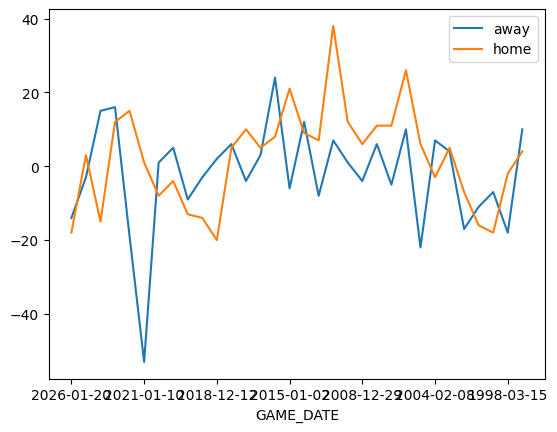

In [43]:
fig, ax = plt.subplots()

games_away.plot(x='GAME_DATE', y='PLUS_MINUS', ax=ax)
games_home.plot(x='GAME_DATE', y='PLUS_MINUS', ax=ax)
ax.legend(['away', 'home'])
plt.show()

In [44]:
# Write your code below and press Shift+Enter to execute
games_home['PTS'].mean()

np.float64(110.1875)

In [45]:
games_away['PTS'].mean()

np.float64(105.3125)